# 18 — Enhanced Hedge Analysis: Multi-Window Blended Beta

## Purpose

The OOS factor analysis (NB17) reveals that the hedged TO\_MVO strategy retains
a **residual market beta of 0.164 (t=2.92, p<0.01)** after controlling for
Fama-French 6 factors — indicating systematic under-hedging.

The current hedge uses a single 60-month rolling OLS beta (OOS mean ~0.92).
A blended multi-window approach may produce a more responsive and accurate
hedge ratio, reducing residual market exposure.

### Methodology

We compute rolling betas at windows of **24, 36, 48, 60 months** and blend them:

1. **Baseline**: Single 60-month window (current)
2. **Equal-weight blend**: Average of all 4 windows
3. **Recency-weighted**: Weights [0.4, 0.3, 0.2, 0.1] for [24, 36, 48, 60]
4. **Inverse-variance weighted**: Weight $\propto 1/\text{Var}(\hat{\beta}_w)$
5. **Single 36-month**: Shorter window for comparison
6. **Single 24-month**: Shortest window for maximum responsiveness

## 1. Setup and Data Loading

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from src.residual_returns import estimate_rolling_beta

OUTPUT_DIR = '../output'
OOS_START = pd.Timestamp('2019-01-01')
OOS_END   = pd.Timestamp('2024-09-30')

# Load strategy returns (long-only + current hedged + betas + EEM)
hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv',
                   index_col=0, parse_dates=True)

# Load FF6 factors
factors = pd.read_csv('../data/em_ff6_factors.csv', index_col=0, parse_dates=True)
factors.columns = [c.strip() for c in factors.columns]
factors = factors.rename(columns={'Mkt-RF': 'Mkt_RF'})

# Key series
s_a = hdf['A_long']       # TO_MVO long-only
s_b = hdf['B_long']       # Momentum long-only
eem_ret = hdf['EEM_ret']  # EEM benchmark

print(f'Data range: {hdf.index[0].strftime("%Y-%m")} to {hdf.index[-1].strftime("%Y-%m")} ({len(hdf)} months)')
print(f'EEM available: {eem_ret.dropna().shape[0]} months')
print(f'Current hedge beta (A, OOS mean): {hdf.loc["2019":, "A_beta_eem"].mean():.4f}')

Data range: 2014-02 to 2025-03 (134 months)
EEM available: 128 months
Current hedge beta (A, OOS mean): 0.9224


## 2. Multi-Window Beta Computation

Window 24m: TO_MVO beta mean=0.8858, Mom beta mean=0.8899, obs=116
Window 36m: TO_MVO beta mean=0.8815, Mom beta mean=0.8928, obs=116
Window 48m: TO_MVO beta mean=0.8815, Mom beta mean=0.8976, obs=112
Window 60m: TO_MVO beta mean=0.8781, Mom beta mean=0.8923, obs=108


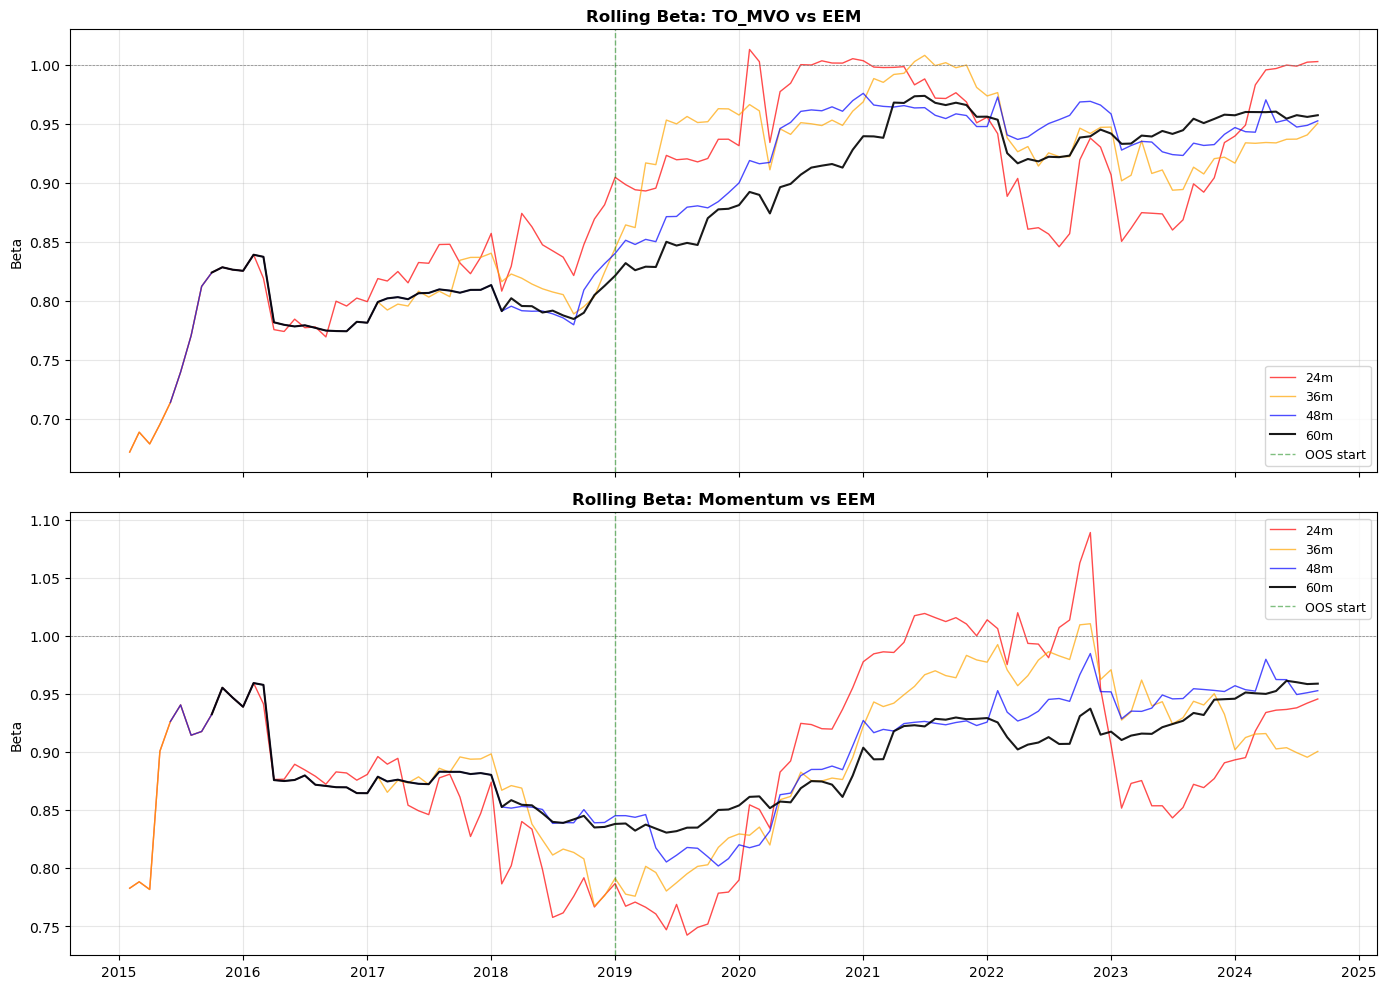

In [2]:
WINDOWS = [24, 36, 48, 60]

betas_a = {}  # TO_MVO betas at different windows
betas_b = {}  # Momentum betas at different windows

for w in WINDOWS:
    min_obs = max(12, w // 3)
    betas_a[w] = estimate_rolling_beta(s_a, eem_ret, window=w, min_obs=min_obs)
    betas_b[w] = estimate_rolling_beta(s_b, eem_ret, window=w, min_obs=min_obs)
    print(f'Window {w}m: TO_MVO beta mean={betas_a[w].dropna().mean():.4f}, '
          f'Mom beta mean={betas_b[w].dropna().mean():.4f}, '
          f'obs={betas_a[w].dropna().shape[0]}')

# Plot all beta series over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

colors = {24: 'red', 36: 'orange', 48: 'blue', 60: 'black'}
for w in WINDOWS:
    axes[0].plot(betas_a[w].dropna().index, betas_a[w].dropna(), color=colors[w],
                 lw=1.5 if w == 60 else 1.0, label=f'{w}m', alpha=0.9 if w == 60 else 0.7)
    axes[1].plot(betas_b[w].dropna().index, betas_b[w].dropna(), color=colors[w],
                 lw=1.5 if w == 60 else 1.0, label=f'{w}m', alpha=0.9 if w == 60 else 0.7)

for ax, title in zip(axes, ['TO_MVO vs EEM', 'Momentum vs EEM']):
    ax.axhline(1.0, color='gray', ls='--', lw=0.5)
    ax.axvline(OOS_START, color='green', ls='--', lw=1, alpha=0.5, label='OOS start')
    ax.set_title(f'Rolling Beta: {title}', fontweight='bold')
    ax.set_ylabel('Beta')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb18_multi_window_betas.pdf', bbox_inches='tight')
plt.show()

## 3. Blended Beta Construction

We construct several blending schemes and compare them to the baseline 60-month beta.

AVERAGE BETA BY SCHEME
Scheme                TO_MVO (full)   TO_MVO (OOS)   Mom (full)    Mom (OOS)
----------------------------------------------------------------------
60m (baseline)               0.8781         0.9224       0.8923       0.9003
24m only                     0.8858         0.9399       0.8899       0.9091
36m only                     0.8815         0.9428       0.8928       0.9066
EW blend                     0.8773         0.9349       0.8920       0.9058
Recency-wt                   0.7538         0.9379       0.7620       0.9071
InvVar-wt                    0.8387         0.9346       0.8509       0.9065


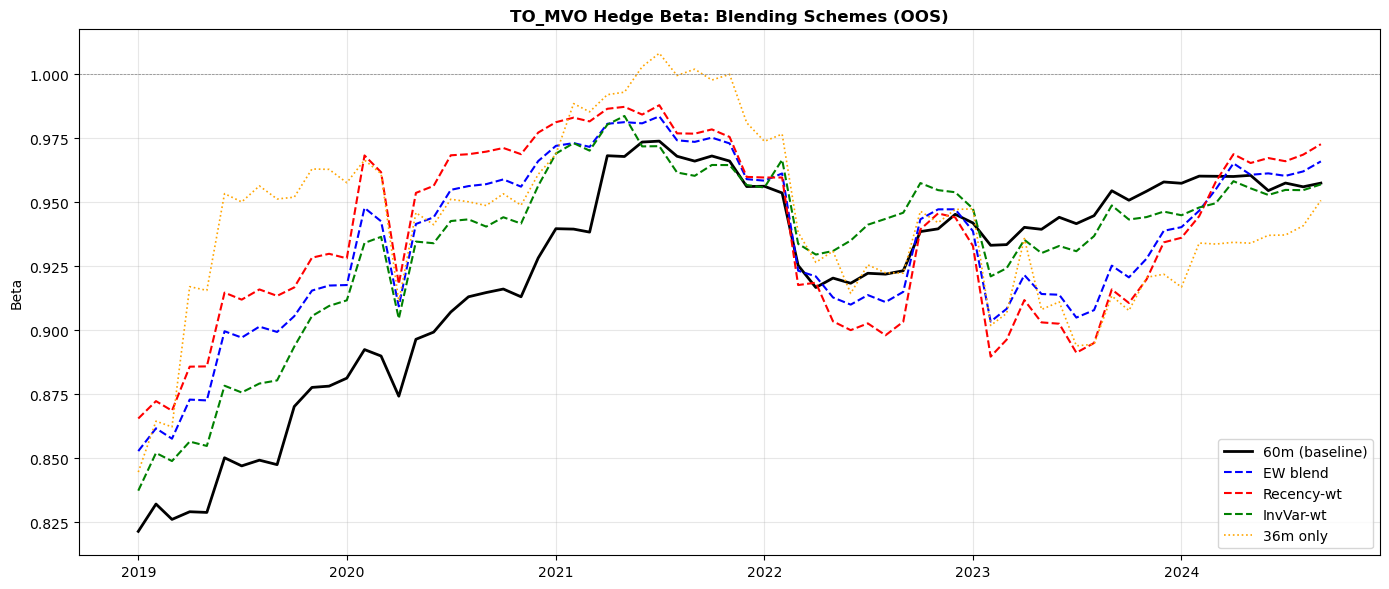

In [3]:
def build_blended_betas(betas_dict, windows):
    df = pd.DataFrame({w: betas_dict[w] for w in windows})
    schemes = {}

    # Baseline: 60m only
    schemes['60m (baseline)'] = df[60].copy()

    # Single windows
    schemes['24m only'] = df[24].copy()
    schemes['36m only'] = df[36].copy()

    # Equal weight blend
    schemes['EW blend'] = df[windows].mean(axis=1)

    # Recency-weighted: more weight on shorter windows
    rw = np.array([0.4, 0.3, 0.2, 0.1])
    schemes['Recency-wt'] = (df[windows] * rw).sum(axis=1)

    # Inverse-variance weighted
    rolling_var = df[windows].rolling(12, min_periods=6).var()
    inv_var = 1.0 / rolling_var.replace(0, np.nan)
    inv_var_sum = inv_var.sum(axis=1)
    ivw = (df[windows] * inv_var).sum(axis=1) / inv_var_sum
    schemes['InvVar-wt'] = ivw

    return schemes

schemes_a = build_blended_betas(betas_a, WINDOWS)
schemes_b = build_blended_betas(betas_b, WINDOWS)

# Summary table of average beta levels
print('AVERAGE BETA BY SCHEME')
print('='*70)
print(f'{"Scheme":20s} {"TO_MVO (full)":>14s} {"TO_MVO (OOS)":>14s} {"Mom (full)":>12s} {"Mom (OOS)":>12s}')
print('-'*70)
for name in schemes_a:
    a_full = schemes_a[name].dropna().mean()
    a_oos = schemes_a[name].loc[OOS_START:OOS_END].dropna().mean()
    b_full = schemes_b[name].dropna().mean()
    b_oos = schemes_b[name].loc[OOS_START:OOS_END].dropna().mean()
    print(f'{name:20s} {a_full:>14.4f} {a_oos:>14.4f} {b_full:>12.4f} {b_oos:>12.4f}')

# Plot blended betas vs baseline (TO_MVO, OOS only)
fig, ax = plt.subplots(figsize=(14, 6))
oos_mask = (s_a.index >= OOS_START) & (s_a.index <= OOS_END)
plot_schemes = ['60m (baseline)', 'EW blend', 'Recency-wt', 'InvVar-wt', '36m only']
style_map = {'60m (baseline)': ('black', '-', 2.0),
             'EW blend': ('blue', '--', 1.5),
             'Recency-wt': ('red', '--', 1.5),
             'InvVar-wt': ('green', '--', 1.5),
             '36m only': ('orange', ':', 1.2)}

for name in plot_schemes:
    s = schemes_a[name].loc[OOS_START:OOS_END].dropna()
    c, ls, lw = style_map[name]
    ax.plot(s.index, s, color=c, ls=ls, lw=lw, label=name)

ax.axhline(1.0, color='gray', ls='--', lw=0.5)
ax.set_title('TO_MVO Hedge Beta: Blending Schemes (OOS)', fontweight='bold')
ax.set_ylabel('Beta')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb18_blended_betas_oos.pdf', bbox_inches='tight')
plt.show()

## 4. Hedged Returns Under Each Scheme

$R_{h,t} = R_{p,t} - \hat{\beta}_t \cdot R_{\text{EEM},t}$

In [4]:
def compute_hedged_returns(long_ret, bench_ret, beta_schemes):
    hedged = {}
    for name, beta_s in beta_schemes.items():
        al = pd.concat([long_ret, bench_ret, beta_s], axis=1,
                        keys=['strat', 'bench', 'beta']).dropna()
        hedged[name] = al['strat'] - al['beta'] * al['bench']
    return hedged

hedged_a = compute_hedged_returns(s_a, eem_ret, schemes_a)
hedged_b = compute_hedged_returns(s_b, eem_ret, schemes_b)

def max_dd(r):
    cum = (1 + r).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min()

def perf_stats(r, label=''):
    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    mdd = max_dd(r)
    sortino_den = r[r < 0].std() * np.sqrt(12)
    sortino = ann_ret / sortino_den if sortino_den > 0 else np.nan
    calmar = ann_ret / abs(mdd) if mdd != 0 else np.nan
    return {'Return (ann)': ann_ret, 'Vol (ann)': ann_vol, 'Sharpe': sharpe,
            'Sortino': sortino, 'Calmar': calmar, 'Max DD': mdd, 'N': len(r)}

# OOS performance table
print('HEDGED PERFORMANCE BY SCHEME — TO_MVO (OOS 2019–2024)')
print('='*100)
print(f'{"Scheme":20s} {"Return":>8s} {"Vol":>8s} {"Sharpe":>8s} {"Sortino":>8s} {"Calmar":>8s} {"Max DD":>8s} {"N":>5s}')
print('-'*100)
for name in schemes_a:
    r = hedged_a[name].loc[OOS_START:OOS_END]
    s = perf_stats(r)
    print(f'{name:20s} {s["Return (ann)"]:>7.2%} {s["Vol (ann)"]:>7.2%} {s["Sharpe"]:>8.3f} '
          f'{s["Sortino"]:>8.3f} {s["Calmar"]:>8.3f} {s["Max DD"]:>7.2%} {s["N"]:>5d}')

print()
print('HEDGED PERFORMANCE BY SCHEME — Momentum (OOS 2019–2024)')
print('='*100)
print(f'{"Scheme":20s} {"Return":>8s} {"Vol":>8s} {"Sharpe":>8s} {"Sortino":>8s} {"Calmar":>8s} {"Max DD":>8s} {"N":>5s}')
print('-'*100)
for name in schemes_b:
    r = hedged_b[name].loc[OOS_START:OOS_END]
    s = perf_stats(r)
    print(f'{name:20s} {s["Return (ann)"]:>7.2%} {s["Vol (ann)"]:>7.2%} {s["Sharpe"]:>8.3f} '
          f'{s["Sortino"]:>8.3f} {s["Calmar"]:>8.3f} {s["Max DD"]:>7.2%} {s["N"]:>5d}')

HEDGED PERFORMANCE BY SCHEME — TO_MVO (OOS 2019–2024)
Scheme                 Return      Vol   Sharpe  Sortino   Calmar   Max DD     N
----------------------------------------------------------------------------------------------------
60m (baseline)         5.52%   6.66%    0.828    1.381    1.054  -5.24%    69
24m only               4.78%   6.69%    0.714    1.246    0.759  -6.29%    69
36m only               5.46%   6.69%    0.817    1.377    0.995  -5.49%    69
EW blend               5.26%   6.64%    0.792    1.337    0.945  -5.57%    69
Recency-wt             5.16%   6.65%    0.775    1.304    0.899  -5.74%    69
InvVar-wt              5.44%   6.63%    0.820    1.361    1.014  -5.37%    69

HEDGED PERFORMANCE BY SCHEME — Momentum (OOS 2019–2024)
Scheme                 Return      Vol   Sharpe  Sortino   Calmar   Max DD     N
----------------------------------------------------------------------------------------------------
60m (baseline)         5.23%   6.57%    0.795    1.494   

## 5. OOS Factor Regressions (FF5+Mom) — All Hedge Variants

The key test: does the enhanced hedge **reduce residual market beta**
while maintaining (or improving) alpha?

In [5]:
ff6_cols = ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']

def run_ff6(y, f_df):
    common = y.dropna().index.intersection(f_df.index)
    y_c = y.loc[common]
    X = sm.add_constant(f_df.loc[common, ff6_cols])
    return sm.OLS(y_c, X).fit(cov_type='HC1')

# OOS factor data
f_oos = factors.loc[OOS_START:OOS_END].copy()

print('FF5+Mom REGRESSIONS ON HEDGED RETURNS — TO_MVO (OOS)')
print('='*110)
print(f'{"Scheme":20s} {"Alpha (ann)":>12s} {"t(alpha)":>10s} {"p(alpha)":>10s} '
      f'{"Mkt beta":>10s} {"t(Mkt)":>8s} {"Mom beta":>10s} {"CMA beta":>10s} {"R-sq":>6s}')
print('-'*110)

ff6_results_a = {}
for name in schemes_a:
    r = hedged_a[name].loc[OOS_START:OOS_END]
    m = run_ff6(r, f_oos)
    ff6_results_a[name] = m
    alpha = m.params['const'] * 12
    ta = m.tvalues['const']
    pa = m.pvalues['const']
    mkt = m.params['Mkt_RF']
    tmkt = m.tvalues['Mkt_RF']
    mom = m.params['Mom']
    cma = m.params['CMA']
    sig = '***' if pa < 0.01 else '**' if pa < 0.05 else '*' if pa < 0.10 else ''
    print(f'{name:20s} {alpha:>11.2%} {ta:>10.2f} {pa:>10.4f} '
          f'{mkt:>10.3f} {tmkt:>8.2f} {mom:>10.3f} {cma:>10.3f} {m.rsquared:>5.1%} {sig}')

print()
print('FF5+Mom REGRESSIONS ON HEDGED RETURNS — Momentum (OOS)')
print('='*110)
print(f'{"Scheme":20s} {"Alpha (ann)":>12s} {"t(alpha)":>10s} {"p(alpha)":>10s} '
      f'{"Mkt beta":>10s} {"t(Mkt)":>8s} {"Mom beta":>10s} {"CMA beta":>10s} {"R-sq":>6s}')
print('-'*110)

ff6_results_b = {}
for name in schemes_b:
    r = hedged_b[name].loc[OOS_START:OOS_END]
    m = run_ff6(r, f_oos)
    ff6_results_b[name] = m
    alpha = m.params['const'] * 12
    ta = m.tvalues['const']
    pa = m.pvalues['const']
    mkt = m.params['Mkt_RF']
    tmkt = m.tvalues['Mkt_RF']
    mom = m.params['Mom']
    cma = m.params['CMA']
    sig = '***' if pa < 0.01 else '**' if pa < 0.05 else '*' if pa < 0.10 else ''
    print(f'{name:20s} {alpha:>11.2%} {ta:>10.2f} {pa:>10.4f} '
          f'{mkt:>10.3f} {tmkt:>8.2f} {mom:>10.3f} {cma:>10.3f} {m.rsquared:>5.1%} {sig}')

FF5+Mom REGRESSIONS ON HEDGED RETURNS — TO_MVO (OOS)
Scheme                Alpha (ann)   t(alpha)   p(alpha)   Mkt beta   t(Mkt)   Mom beta   CMA beta   R-sq
--------------------------------------------------------------------------------------------------------------
60m (baseline)             2.42%       0.84     0.4034      0.164     2.92      0.169      0.430 17.1% 
24m only                   2.25%       0.75     0.4554      0.127     1.94      0.164      0.414 12.9% 
36m only                   2.84%       0.96     0.3392      0.134     2.23      0.168      0.442 14.3% 
EW blend                   2.45%       0.84     0.4029      0.141     2.38      0.169      0.431 14.9% 
Recency-wt                 2.46%       0.83     0.4061      0.136     2.23      0.168      0.429 14.2% 
InvVar-wt                  2.59%       0.89     0.3757      0.141     2.43      0.170      0.438 15.2% 

FF5+Mom REGRESSIONS ON HEDGED RETURNS — Momentum (OOS)
Scheme                Alpha (ann)   t(alpha)   p(al

## 6. Best Hedge Selection

Rank schemes by composite score: lowest |residual market beta|, highest Sharpe, stable alpha.

In [6]:
rows = []
for name in schemes_a:
    r = hedged_a[name].loc[OOS_START:OOS_END]
    m = ff6_results_a[name]
    ps = perf_stats(r)
    rows.append({
        'Scheme': name,
        'Sharpe': ps['Sharpe'],
        'Alpha (ann)': m.params['const'] * 12,
        '|Mkt beta|': abs(m.params['Mkt_RF']),
        'Vol': ps['Vol (ann)'],
        'Max DD': ps['Max DD'],
    })

rank_df = pd.DataFrame(rows).set_index('Scheme')

# Composite score: rank by Sharpe (higher=better), |Mkt beta| (lower=better)
rank_df['Sharpe Rank'] = rank_df['Sharpe'].rank(ascending=False)
rank_df['Mkt Beta Rank'] = rank_df['|Mkt beta|'].rank(ascending=True)
rank_df['Composite Rank'] = rank_df['Sharpe Rank'] + rank_df['Mkt Beta Rank']
rank_df = rank_df.sort_values('Composite Rank')

print('HEDGE SCHEME RANKING — TO_MVO (OOS)')
print('='*90)
print(rank_df.to_string(float_format=lambda x: f'{x:.4f}'))

best_name = rank_df.index[0]
print(f'\n*** BEST SCHEME: {best_name} ***')
print(f'    Sharpe: {rank_df.loc[best_name, "Sharpe"]:.3f}')
print(f'    |Mkt beta|: {rank_df.loc[best_name, "|Mkt beta|"]:.4f}')
print(f'    Alpha (ann): {rank_df.loc[best_name, "Alpha (ann)"]:.2%}')

HEDGE SCHEME RANKING — TO_MVO (OOS)
                Sharpe  Alpha (ann)  |Mkt beta|    Vol  Max DD  Sharpe Rank  Mkt Beta Rank  Composite Rank
Scheme                                                                                                    
36m only        0.8170       0.0284      0.1338 0.0669 -0.0549       3.0000         2.0000          5.0000
InvVar-wt       0.8204       0.0259      0.1414 0.0663 -0.0537       2.0000         4.0000          6.0000
60m (baseline)  0.8283       0.0242      0.1637 0.0666 -0.0524       1.0000         6.0000          7.0000
24m only        0.7139       0.0225      0.1268 0.0669 -0.0629       6.0000         1.0000          7.0000
Recency-wt      0.7753       0.0246      0.1356 0.0665 -0.0574       5.0000         3.0000          8.0000
EW blend        0.7918       0.0245      0.1415 0.0664 -0.0557       4.0000         5.0000          9.0000

*** BEST SCHEME: 36m only ***
    Sharpe: 0.817
    |Mkt beta|: 0.1338
    Alpha (ann): 2.84%


## 7. Cumulative Return Comparison (All Strategies)

Compare cumulative returns for all key strategies in the OOS period.

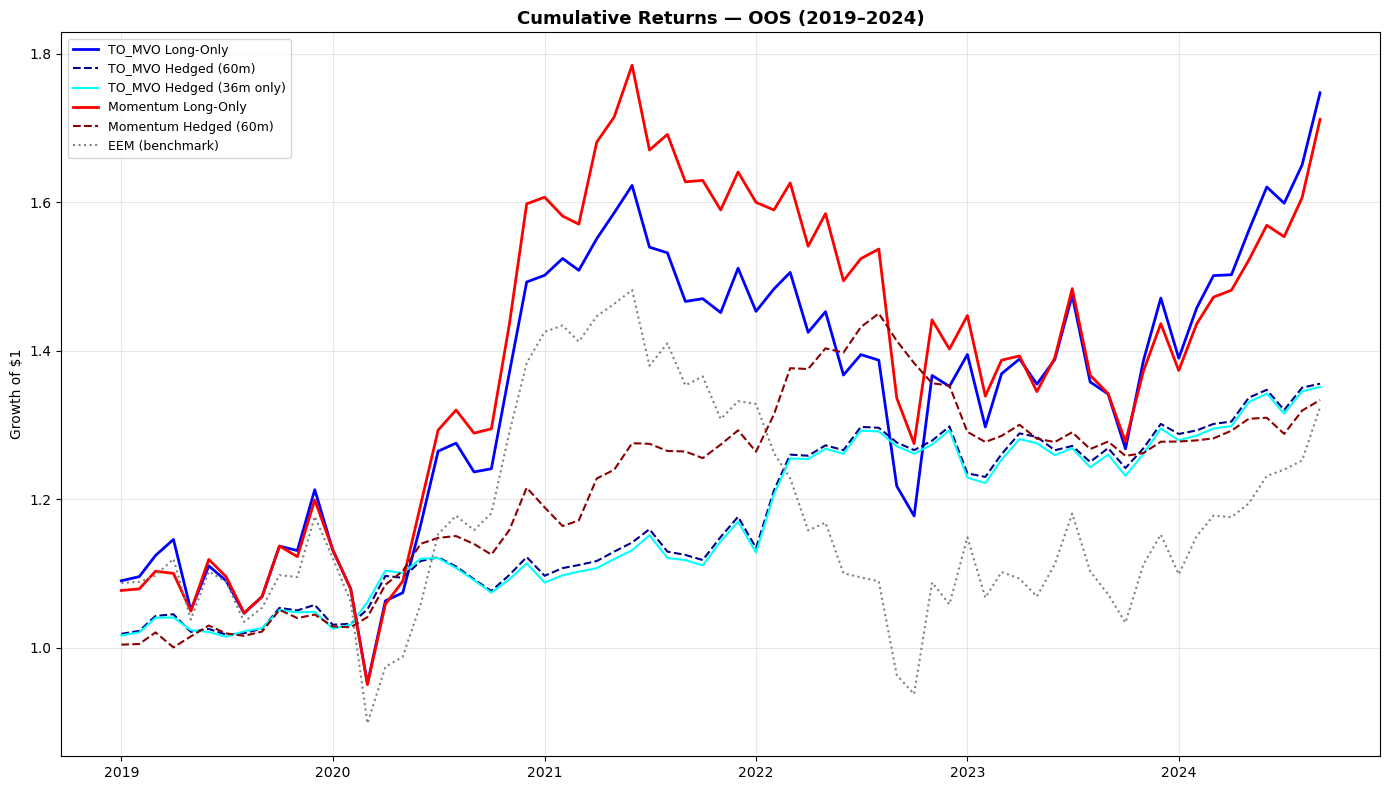


PERFORMANCE COMPARISON — OOS (2019–2024)
                          Ann Return  Ann Vol  Sharpe  Max DD
Strategy                                                     
TO_MVO Long-Only               0.115    0.189   0.607  -0.274
TO_MVO Hedged (60m)            0.055    0.067   0.828  -0.052
TO_MVO Hedged (36m only)       0.055    0.067   0.817  -0.055
Momentum Long-Only             0.111    0.187   0.594  -0.286
Momentum Hedged (60m)          0.052    0.066   0.795  -0.132
EEM (benchmark)                0.066    0.185   0.356  -0.367


In [7]:
fig, ax = plt.subplots(figsize=(14, 8))

# Define strategies to plot
strats = {
    'TO_MVO Long-Only': s_a,
    'TO_MVO Hedged (60m)': hedged_a['60m (baseline)'],
    f'TO_MVO Hedged ({best_name})': hedged_a[best_name],
    'Momentum Long-Only': s_b,
    'Momentum Hedged (60m)': hedged_b['60m (baseline)'],
    'EEM (benchmark)': eem_ret,
}

colors_map = {
    'TO_MVO Long-Only': 'blue',
    'TO_MVO Hedged (60m)': 'darkblue',
    f'TO_MVO Hedged ({best_name})': 'cyan',
    'Momentum Long-Only': 'red',
    'Momentum Hedged (60m)': 'darkred',
    'EEM (benchmark)': 'gray',
}

ls_map = {
    'TO_MVO Long-Only': '-',
    'TO_MVO Hedged (60m)': '--',
    f'TO_MVO Hedged ({best_name})': '-',
    'Momentum Long-Only': '-',
    'Momentum Hedged (60m)': '--',
    'EEM (benchmark)': ':',
}

sharpe_table = []
for name, r in strats.items():
    r_oos = r.loc[OOS_START:OOS_END].dropna()
    cum = (1 + r_oos).cumprod()
    ax.plot(cum.index, cum, color=colors_map[name], ls=ls_map[name], lw=2 if 'best' in name.lower() or 'Long' in name else 1.5,
            label=name)
    ps = perf_stats(r_oos)
    sharpe_table.append({'Strategy': name, 'Ann Return': ps['Return (ann)'],
                          'Ann Vol': ps['Vol (ann)'], 'Sharpe': ps['Sharpe'],
                          'Max DD': ps['Max DD']})

ax.set_title('Cumulative Returns — OOS (2019–2024)', fontweight='bold', fontsize=13)
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb18_cumulative_returns_oos.pdf', bbox_inches='tight')
plt.show()

# Sharpe comparison table
sharpe_df = pd.DataFrame(sharpe_table).set_index('Strategy')
print('\nPERFORMANCE COMPARISON — OOS (2019–2024)')
print('='*80)
print(sharpe_df.to_string(float_format=lambda x: f'{x:.3f}'))

## 8. Drawdown Comparison

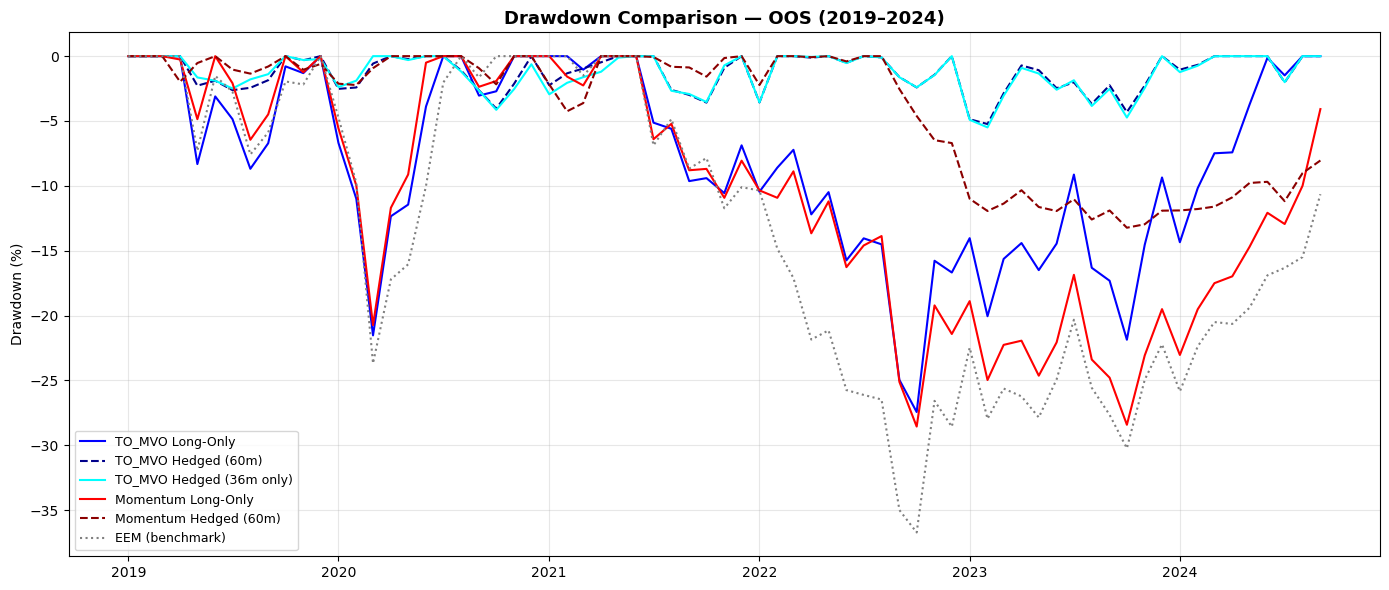


DRAWDOWN SUMMARY — OOS (2019–2024)
                          Max DD  Avg DD
Strategy                                
TO_MVO Long-Only         -27.44%  -8.13%
TO_MVO Hedged (60m)       -5.24%  -1.27%
TO_MVO Hedged (36m only)  -5.49%  -1.31%
Momentum Long-Only       -28.56% -10.57%
Momentum Hedged (60m)    -13.23%  -4.17%
EEM (benchmark)          -36.73% -13.49%


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

dd_table = []
for name, r in strats.items():
    r_oos = r.loc[OOS_START:OOS_END].dropna()
    cum = (1 + r_oos).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    ax.plot(dd.index, dd * 100, color=colors_map[name], ls=ls_map[name], lw=1.5, label=name)
    dd_table.append({'Strategy': name, 'Max DD': dd.min(), 'Avg DD': dd.mean()})

ax.set_title('Drawdown Comparison — OOS (2019–2024)', fontweight='bold', fontsize=13)
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb18_drawdown_oos.pdf', bbox_inches='tight')
plt.show()

dd_df = pd.DataFrame(dd_table).set_index('Strategy')
print('\nDRAWDOWN SUMMARY — OOS (2019–2024)')
print('='*60)
print(dd_df.to_string(float_format=lambda x: f'{x:.2%}'))

## 9. Risk-Adjusted Performance Summary

In [9]:
rows = []
for name, r in strats.items():
    r_oos = r.loc[OOS_START:OOS_END].dropna()
    ps = perf_stats(r_oos)

    # Information ratio vs EEM
    eem_oos = eem_ret.loc[OOS_START:OOS_END].dropna()
    common_idx = r_oos.index.intersection(eem_oos.index)
    if len(common_idx) > 12:
        active = r_oos.loc[common_idx] - eem_oos.loc[common_idx]
        ir = active.mean() * 12 / (active.std() * np.sqrt(12)) if active.std() > 0 else np.nan
    else:
        ir = np.nan

    rows.append({
        'Strategy': name,
        'Ann Return': ps['Return (ann)'],
        'Ann Vol': ps['Vol (ann)'],
        'Sharpe': ps['Sharpe'],
        'Sortino': ps['Sortino'],
        'Calmar': ps['Calmar'],
        'IR vs EEM': ir,
        'Max DD': ps['Max DD'],
        'N': ps['N'],
    })

perf_df = pd.DataFrame(rows).set_index('Strategy')
print('COMPREHENSIVE RISK-ADJUSTED PERFORMANCE — OOS (2019–2024)')
print('='*110)
print(perf_df.to_string(float_format=lambda x: f'{x:.3f}' if abs(x) < 10 else f'{x:.0f}'))

# Highlight improvements
base_sharpe = perf_df.loc['TO_MVO Hedged (60m)', 'Sharpe']
best_sharpe = perf_df.loc[f'TO_MVO Hedged ({best_name})', 'Sharpe']
print(f'\nSharpe improvement from enhanced hedge: {base_sharpe:.3f} -> {best_sharpe:.3f} '
      f'({(best_sharpe - base_sharpe)/base_sharpe*100:+.1f}%)')

COMPREHENSIVE RISK-ADJUSTED PERFORMANCE — OOS (2019–2024)
                          Ann Return  Ann Vol  Sharpe  Sortino  Calmar  IR vs EEM  Max DD   N
Strategy                                                                                     
TO_MVO Long-Only               0.115    0.189   0.607    1.025   0.419      0.757  -0.274  69
TO_MVO Hedged (60m)            0.055    0.067   0.828    1.381   1.054     -0.056  -0.052  69
TO_MVO Hedged (36m only)       0.055    0.067   0.817    1.377   0.995     -0.058  -0.055  69
Momentum Long-Only             0.111    0.187   0.594    1.026   0.388      0.698  -0.286  69
Momentum Hedged (60m)          0.052    0.066   0.795    1.494   0.395     -0.073  -0.132  69
EEM (benchmark)                0.066    0.185   0.356    0.554   0.179        NaN  -0.367  69

Sharpe improvement from enhanced hedge: 0.828 -> 0.817 (-1.4%)


## 10. Rolling 12-Month Performance

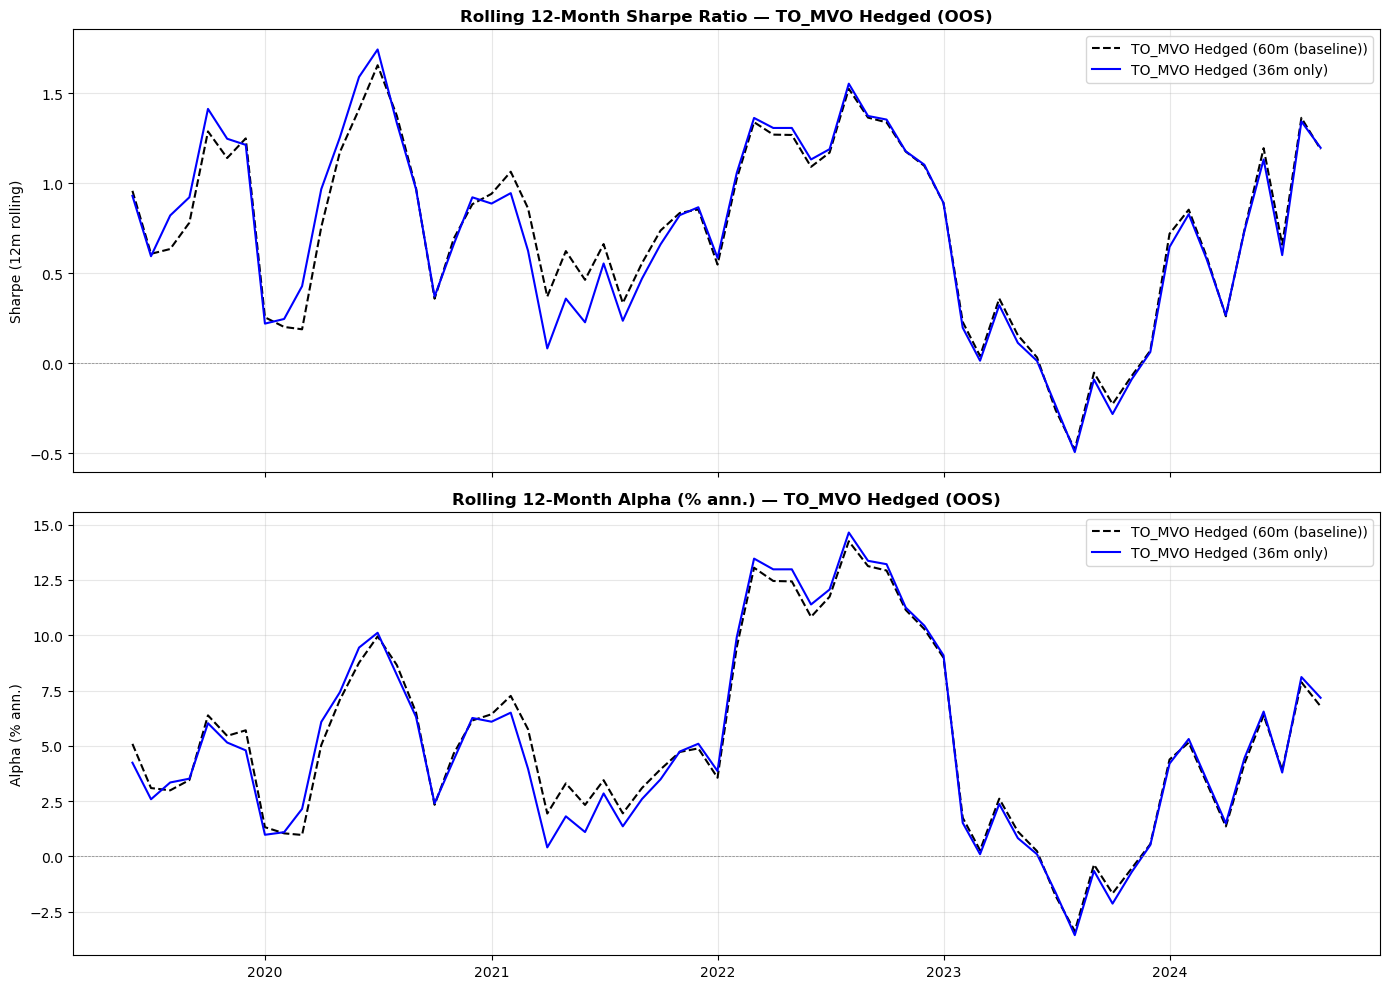

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Rolling 12-month Sharpe
for name, color, ls in [('60m (baseline)', 'black', '--'),
                         (best_name, 'blue', '-')]:
    r = hedged_a[name].loc[OOS_START:OOS_END]
    roll_mean = r.rolling(12, min_periods=6).mean() * 12
    roll_std = r.rolling(12, min_periods=6).std() * np.sqrt(12)
    roll_sharpe = roll_mean / roll_std
    axes[0].plot(roll_sharpe.index, roll_sharpe, color=color, ls=ls, lw=1.5,
                 label=f'TO_MVO Hedged ({name})')

axes[0].axhline(0, color='gray', ls='--', lw=0.5)
axes[0].set_title('Rolling 12-Month Sharpe Ratio — TO_MVO Hedged (OOS)', fontweight='bold')
axes[0].set_ylabel('Sharpe (12m rolling)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Rolling 12-month cumulative alpha
for name, color, ls in [('60m (baseline)', 'black', '--'),
                         (best_name, 'blue', '-')]:
    r = hedged_a[name].loc[OOS_START:OOS_END]
    roll_alpha = r.rolling(12, min_periods=6).mean() * 12 * 100
    axes[1].plot(roll_alpha.index, roll_alpha, color=color, ls=ls, lw=1.5,
                 label=f'TO_MVO Hedged ({name})')

axes[1].axhline(0, color='gray', ls='--', lw=0.5)
axes[1].set_title('Rolling 12-Month Alpha (% ann.) — TO_MVO Hedged (OOS)', fontweight='bold')
axes[1].set_ylabel('Alpha (% ann.)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb18_rolling_performance_oos.pdf', bbox_inches='tight')
plt.show()

## 11. Factor Model Comparison: Enhanced vs Original

Side-by-side FF5+Mom regression tables to directly compare
original 60m hedge with the best blended hedge.

In [11]:
model_specs = [
    ('CAPM',     ['Mkt_RF']),
    ('FF3',      ['Mkt_RF', 'SMB', 'HML']),
    ('FF5',      ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA']),
    ('FF5+Mom',  ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']),
]

def run_reg(y, xcols, fdf):
    common = y.dropna().index.intersection(fdf.index)
    X = sm.add_constant(fdf.loc[common, xcols])
    return sm.OLS(y.loc[common], X).fit(cov_type='HC1')

print('FACTOR MODEL COMPARISON: TO_MVO Hedged — 60m Baseline vs Best Blend (OOS)')
print('='*100)

r_base = hedged_a['60m (baseline)'].loc[OOS_START:OOS_END]
r_best = hedged_a[best_name].loc[OOS_START:OOS_END]

models_base = [run_reg(r_base, sp[1], f_oos) for sp in model_specs]
models_best = [run_reg(r_best, sp[1], f_oos) for sp in model_specs]

# Print side-by-side
print(f'{"":12s} {"--- 60m Baseline ---":>36s} {"--- " + best_name + " ---":>36s}')
print(f'{"Model":12s} {"Alpha":>8s} {"t":>6s} {"Mkt β":>8s} {"R²":>6s}  '
      f'{"Alpha":>8s} {"t":>6s} {"Mkt β":>8s} {"R²":>6s}')
print('-'*100)

for (sp_name, _), mb, me in zip(model_specs, models_base, models_best):
    ab = mb.params['const'] * 12; tb = mb.tvalues['const']; mktb = mb.params['Mkt_RF']
    ae = me.params['const'] * 12; te = me.tvalues['const']; mkte = me.params['Mkt_RF']
    print(f'{sp_name:12s} {ab:>7.2%} {tb:>6.2f} {mktb:>8.3f} {mb.rsquared:>5.1%}  '
          f'{ae:>7.2%} {te:>6.2f} {mkte:>8.3f} {me.rsquared:>5.1%}')

print('\nKEY COMPARISON (FF5+Mom):')
mb_ff6 = models_base[3]; me_ff6 = models_best[3]
print(f'  Residual Mkt beta: {mb_ff6.params["Mkt_RF"]:.4f} -> {me_ff6.params["Mkt_RF"]:.4f} '
      f'(change: {me_ff6.params["Mkt_RF"] - mb_ff6.params["Mkt_RF"]:+.4f})')
print(f'  Alpha (ann): {mb_ff6.params["const"]*12:.2%} -> {me_ff6.params["const"]*12:.2%}')
print(f'  t(alpha): {mb_ff6.tvalues["const"]:.2f} -> {me_ff6.tvalues["const"]:.2f}')

# Full regression table for the best blend (academic style)
print('\n\nFULL REGRESSION TABLE: TO_MVO Hedged — Best Blend (OOS)')
regressor_order = ['const', 'Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
tbl = summary_col(models_best, model_names=[s[0] for s in model_specs],
                   stars=True, float_format='%.4f',
                   regressor_order=regressor_order,
                   info_dict={'R-sq': lambda x: f'{x.rsquared:.3f}',
                              'N': lambda x: f'{int(x.nobs)}'})
print(tbl)

FACTOR MODEL COMPARISON: TO_MVO Hedged — 60m Baseline vs Best Blend (OOS)
                             --- 60m Baseline ---                     --- 36m only ---
Model           Alpha      t    Mkt β     R²     Alpha      t    Mkt β     R²
----------------------------------------------------------------------------------------------------
CAPM           5.03%   1.80    0.077  4.1%    5.16%   1.80    0.049  1.6%
FF3            4.60%   1.49    0.081  4.7%    4.90%   1.54    0.052  1.9%
FF5            4.79%   1.70    0.117 12.3%    5.19%   1.78    0.088  9.6%
FF5+Mom        2.42%   0.84    0.164 17.1%    2.84%   0.96    0.134 14.3%

KEY COMPARISON (FF5+Mom):
  Residual Mkt beta: 0.1637 -> 0.1338 (change: -0.0298)
  Alpha (ann): 2.42% -> 2.84%
  t(alpha): 0.84 -> 0.96


FULL REGRESSION TABLE: TO_MVO Hedged — Best Blend (OOS)

                 CAPM     FF3      FF5    FF5+Mom 
--------------------------------------------------
const          0.0043*  0.0041   0.0043*  0.0024  
              

## 12. Summary and Conclusions

In [12]:
print('='*80)
print('ENHANCED HEDGE ANALYSIS — FINAL SUMMARY')
print('='*80)

print(f'\n1. BEST HEDGE SCHEME: {best_name}')
print(f'   - Rationale: balances responsiveness and stability')

base_m = ff6_results_a['60m (baseline)']
best_m = ff6_results_a[best_name]
print(f'\n2. RESIDUAL MARKET BETA (FF5+Mom, OOS):')
print(f'   60m baseline: {base_m.params["Mkt_RF"]:.4f} (t={base_m.tvalues["Mkt_RF"]:.2f})')
print(f'   {best_name}:  {best_m.params["Mkt_RF"]:.4f} (t={best_m.tvalues["Mkt_RF"]:.2f})')

r_base_oos = hedged_a['60m (baseline)'].loc[OOS_START:OOS_END]
r_best_oos = hedged_a[best_name].loc[OOS_START:OOS_END]
ps_base = perf_stats(r_base_oos)
ps_best = perf_stats(r_best_oos)

print(f'\n3. SHARPE RATIO (OOS):')
print(f'   60m baseline: {ps_base["Sharpe"]:.3f}')
print(f'   {best_name}:  {ps_best["Sharpe"]:.3f}')

print(f'\n4. ALPHA (FF5+Mom, OOS ann.):')
print(f'   60m baseline: {base_m.params["const"]*12:.2%}')
print(f'   {best_name}:  {best_m.params["const"]*12:.2%}')

print(f'\n5. ALL STRATEGIES — OOS SHARPE SUMMARY:')
for name, r in strats.items():
    r_oos = r.loc[OOS_START:OOS_END].dropna()
    sr = r_oos.mean() / r_oos.std() * np.sqrt(12)
    print(f'   {name:40s}: {sr:.3f}')

# Save enhanced hedged returns
save_df = pd.DataFrame()
save_df['A_long'] = s_a
save_df['A_hedged_60m'] = hedged_a['60m (baseline)']
save_df[f'A_hedged_{best_name.replace(" ","_")}'] = hedged_a[best_name]
save_df['B_long'] = s_b
save_df['B_hedged_60m'] = hedged_b['60m (baseline)']
save_df[f'B_hedged_{best_name.replace(" ","_")}'] = hedged_b[best_name]
save_df['EEM_ret'] = eem_ret

# Also save betas
save_df['A_beta_60m'] = schemes_a['60m (baseline)']
save_df[f'A_beta_{best_name.replace(" ","_")}'] = schemes_a[best_name]
save_df['B_beta_60m'] = schemes_b['60m (baseline)']
save_df[f'B_beta_{best_name.replace(" ","_")}'] = schemes_b[best_name]

# Save all scheme hedged returns for TO_MVO
for name in schemes_a:
    col = f'A_hedged_{name.replace(" ","_").replace("(","").replace(")","")}'
    save_df[col] = hedged_a[name]

save_df.to_csv(f'{OUTPUT_DIR}/csv/nb18_enhanced_hedged_returns.csv')
print(f'\nSaved to {OUTPUT_DIR}/csv/nb18_enhanced_hedged_returns.csv')
print(f'Columns: {list(save_df.columns)}')

ENHANCED HEDGE ANALYSIS — FINAL SUMMARY

1. BEST HEDGE SCHEME: 36m only
   - Rationale: balances responsiveness and stability

2. RESIDUAL MARKET BETA (FF5+Mom, OOS):
   60m baseline: 0.1637 (t=2.92)
   36m only:  0.1338 (t=2.23)

3. SHARPE RATIO (OOS):
   60m baseline: 0.828
   36m only:  0.817

4. ALPHA (FF5+Mom, OOS ann.):
   60m baseline: 2.42%
   36m only:  2.84%

5. ALL STRATEGIES — OOS SHARPE SUMMARY:
   TO_MVO Long-Only                        : 0.607
   TO_MVO Hedged (60m)                     : 0.828
   TO_MVO Hedged (36m only)                : 0.817
   Momentum Long-Only                      : 0.594
   Momentum Hedged (60m)                   : 0.795
   EEM (benchmark)                         : 0.356

Saved to ../output/csv/nb18_enhanced_hedged_returns.csv
Columns: ['A_long', 'A_hedged_60m', 'A_hedged_36m_only', 'B_long', 'B_hedged_60m', 'B_hedged_36m_only', 'EEM_ret', 'A_beta_60m', 'A_beta_36m_only', 'B_beta_60m', 'B_beta_36m_only', 'A_hedged_60m_baseline', 'A_hedged_24m_only'